Task 2.2 Supervised preprocessing and visualization

In [110]:

import pandas as pd
import numpy as np
# load dataset diabetes.csv
# index column is set to class tested positive or negative, so it is not included in the data frame
diabetes = pd.read_csv("diabetes.csv", index_col=8)
print(diabetes.head())


                 preg  plas  pres  skin  insu  mass   pedi  age
class                                                          
tested_positive     6   148    72    35     0  33.6  0.627   50
tested_negative     1    85    66    29     0  26.6  0.351   31
tested_positive     8   183    64     0     0  23.3  0.672   32
tested_negative     1    89    66    23    94  28.1  0.167   21
tested_positive     0   137    40    35   168  43.1  2.288   33


In [111]:
# change column class to numeric value (0 for tested_negative, 1 for tested_positive)


# save new dataframe as diabetes_numeric
# diabetes_numeric = diabetes.copy()
# diabetes_numeric['class'] = diabetes_numeric['class'].map({'tested_negative': 0, 'tested_positive': 1})
# print(diabetes_numeric.head())

In [112]:
# define and apply IQR- based outlier detection


# mark values outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR] as outliers  
Q1 = diabetes.quantile(0.25)
Q3 = diabetes.quantile(0.75)
IQR = Q3 - Q1
# create a boolean dataframe where True indicates an outlier
outliers = (diabetes < (Q1 - 1.5 * IQR)) | (diabetes > (Q3 + 1.5 * IQR))
print( 'number of outliers:\n' + str(outliers.sum()) )
print(outliers.head())

number of outliers:
preg     4
plas     5
pres    45
skin     1
insu    34
mass    19
pedi    29
age      9
dtype: int64
                  preg   plas   pres   skin   insu   mass   pedi    age
class                                                                  
tested_positive  False  False  False  False  False  False  False  False
tested_negative  False  False  False  False  False  False  False  False
tested_positive  False  False  False  False  False  False  False  False
tested_negative  False  False  False  False  False  False  False  False
tested_positive  False  False  False  False  False  False   True  False


In [113]:
# Replace outliers with NA and select complete cases
# replace outliers with NA using numpy.nan
diabetes[outliers] = np.nan
print(f"Number of rows in diabetes dataframe before cleaning: {diabetes.shape[0]}")

# consider meaning of zeroes: 
# zeroes should be treated as missing values for plas, skin, insu, mass, pedi, age
diabetes[['plas', 'skin', 'insu', 'mass', 'pedi', 'age']] = diabetes[['plas', 'skin', 'insu', 'mass', 'pedi', 'age']].replace(0, np.nan)
print(diabetes.head())

# drop rows with missing values using dropna()
diabetes_cleaned = diabetes.dropna()
print(f"Number of rows in diabetes_cleaned dataframe: {diabetes_cleaned.shape[0]}")


Number of rows in diabetes dataframe before cleaning: 768
                 preg   plas  pres  skin   insu  mass   pedi   age
class                                                             
tested_positive   6.0  148.0  72.0  35.0    NaN  33.6  0.627  50.0
tested_negative   1.0   85.0  66.0  29.0    NaN  26.6  0.351  31.0
tested_positive   8.0  183.0  64.0   NaN    NaN  23.3  0.672  32.0
tested_negative   1.0   89.0  66.0  23.0   94.0  28.1  0.167  21.0
tested_positive   0.0  137.0  40.0  35.0  168.0  43.1    NaN  33.0
Number of rows in diabetes_cleaned dataframe: 332


In [114]:
# Describe single features 
# use pandas.describe() for summary statistics of the features
print(diabetes_cleaned.describe().round(2))


         preg    plas    pres    skin    insu    mass    pedi     age
count  332.00  332.00  332.00  332.00  332.00  332.00  332.00  332.00
mean     3.18  118.90   70.72   28.42  126.90   32.43    0.47   30.23
std      3.02   29.21   11.40   10.32   66.66    6.38    0.25    9.42
min      0.00   56.00   38.00    7.00   15.00   18.20    0.08   21.00
25%      1.00   97.75   62.00   20.00   74.75   27.80    0.27   23.00
50%      2.00  114.50   70.00   28.00  115.50   32.85    0.43   27.00
75%      5.00  136.25   78.00   36.00  168.50   36.50    0.65   35.25
max     13.00  198.00  106.00   60.00  318.00   49.70    1.19   63.00


Pima Indians Diabetes Dataset:\ 
preg: number of Pregnancies\
plas: Plasma glucose\
pres: Diastolic Blood Pressure (mmHg)\
skin: Skin fold thickness (mm)\
insu: 2 hour serum insulin (mu/ml)\ 
mass: BMI\
pedi: likelihood of diabetes based on family history

In [115]:
# Rank features using mutual information
from sklearn.feature_selection import mutual_info_classif
# separate features and target variable
# target variable is the index (class tested positive or negative for diabetes)
X = diabetes_cleaned
y = diabetes_cleaned.index  
# compute mutual information scores (returns an array of MI scores for each feature)
mi_scores = mutual_info_classif(X, y, random_state=42)
# create a Series with feature names and their corresponding MI scores
mi_series = pd.Series(mi_scores, index=X.columns)
print(mi_series.sort_values(ascending=False))

plas    0.136900
age     0.071330
insu    0.067589
mass    0.048542
preg    0.034221
pres    0.008131
skin    0.000000
pedi    0.000000
dtype: float64


Mutual information: Plas, age, insu haben den größten Einfluss auf positiven Diabetes Test\ 
Macht sinn denn Blutglucose ist die Diagnosestellung von Diabetes, Insulin ist bei Diabetes reduziert. Age ist auch nachvollziehbar, mit dem Alter nimmt das Diabetesrisiko auch zu. Interessanterweise hat die positive Familienanamnese (pedi) hier keinen Einfluss auf die Diabetesdiagnose.


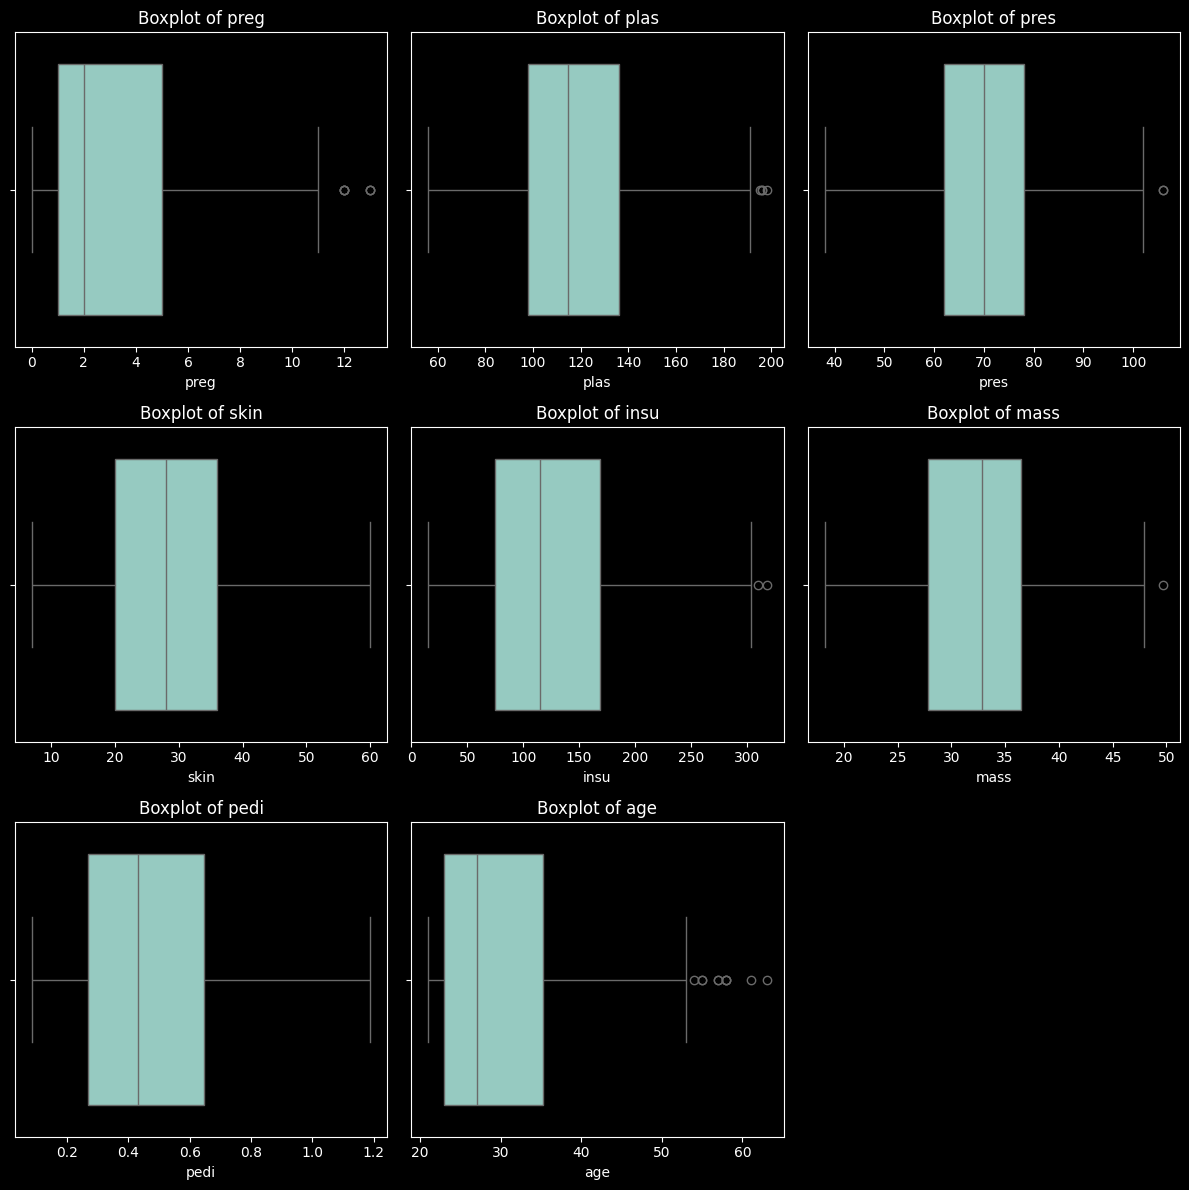

In [116]:
# create boxpplot and distribution plots, use seaborn
import seaborn as sns
import matplotlib.pyplot as plt
# boxplot for each feature, display them in a grid of 3 rows and 3 columns  
plt.figure(figsize=(12, 12))
for i, column in enumerate(diabetes_cleaned.columns):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x=diabetes_cleaned[column])
    plt.title(f'Boxplot of {column}')
plt.tight_layout()
plt.show()

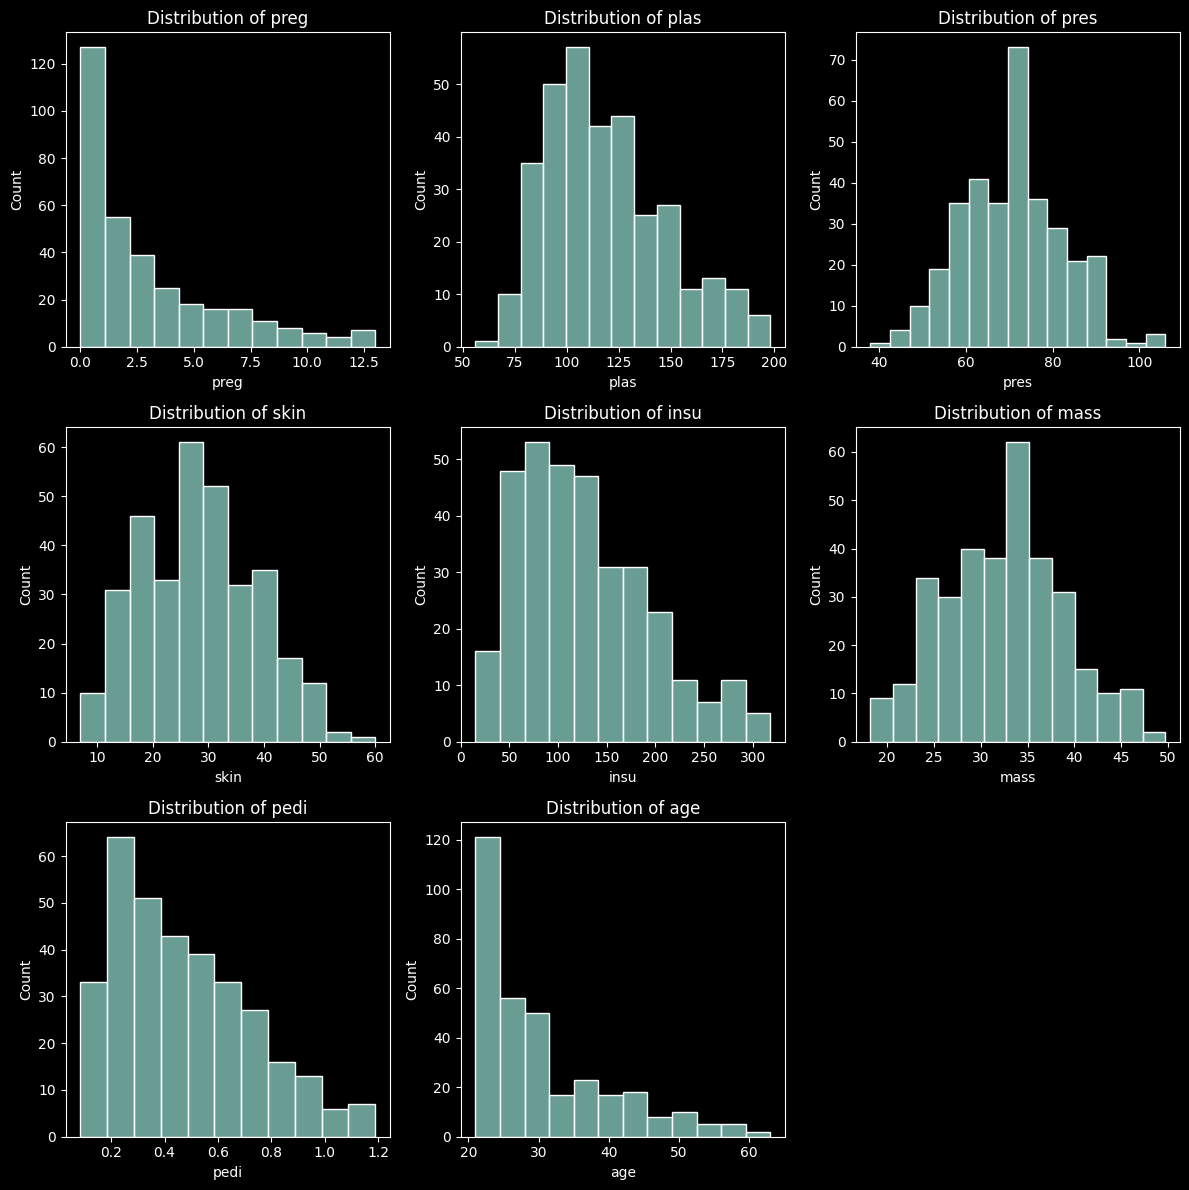

In [117]:
# create distribution plots for each feature
plt.figure(figsize=(12, 12))
for i, column in enumerate(diabetes_cleaned.columns):
    plt.subplot(3, 3, i + 1)
    sns.histplot(diabetes_cleaned[column])
    plt.title(f'Distribution of {column}')
plt.tight_layout()
plt.show()

# create distribution plot using matplotlib
# plt.figure(figsize=(12, 12))
# for i, column in enumerate(diabetes_cleaned.columns):
#     plt.subplot(3, 3, i + 1)
#     plt.hist(diabetes_cleaned[column])
#     plt.title(f'Distribution of {column}')
# plt.tight_layout()
# plt.show()

Studiengruppe ist vom Alter her sehr inhomogen, großteils Probandinnen anfang/mitte 20